## 1. Load Data

The dataset is loaded from the processed SQL output.
It contains transaction-level information, including:

- User information (age, sex)
- Transaction details (purchase value, time)
- Contextual data (country, browser, source)
- Target variable (class):
  - `0` = non-fraudulent transaction
  - `1` = fraudulent transaction

In [8]:
# Import libraries
import pandas as pd

# Load dataset
df = pd.read_csv("../data/processed/fraud_with_country.csv")

# Quick check
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country
0,2,2015-01-11 03:47:13,2015-02-21 10:03:37,54,FGBQNDNBETFJJ,SEO,Chrome,F,25,8.802175e+08,0,United States
1,4,2015-06-02 16:40:57,2015-09-26 21:32:16,41,MKFUIVOHLJBYN,Direct,Safari,F,38,2.785906e+09,0,Australia
2,8,2015-05-28 07:53:06,2015-08-13 11:53:07,47,SCQGQALXBUQZJ,SEO,Chrome,M,25,3.560567e+08,0,Australia
3,9,2015-05-16 15:58:32,2015-05-20 23:06:42,62,IEZOHXPZBIRTE,SEO,FireFox,M,21,7.591047e+08,0,Philippines
4,12,2015-01-10 06:25:12,2015-03-04 20:56:37,35,MSNWCFEHKTIOY,Ads,Safari,M,19,2.985180e+09,0,Australia


## 2. Feature Engineering

We create new features to better capture user behavior.

In particular, we compute the time between account signup
and the purchase, which was identified in the SQL analysis
as a strong indicator of fraud.

In [12]:
df["signup_time"] = pd.to_datetime(df["signup_time"])
df["purchase_time"] = pd.to_datetime(df["purchase_time"])

df["time_to_purchase"] = (
    (df["purchase_time"] - df["signup_time"]).dt.total_seconds() / 60
)

# Check new feature
df[["time_to_purchase", "class"]].head()

# Summary stats
df["time_to_purchase"].describe()

count    131729.000000
mean      82099.180824
std       52177.389102
min           0.016667
25%       36292.616667
50%       82059.033333
75%      127392.633333
max      172799.533333
Name: time_to_purchase, dtype: float64

## 3. Prepare Features for Modeling

Before training the models, the dataset must be transformed into a machine-learning-ready format.

This includes:
- selecting useful predictors
- encoding categorical variables
- excluding columns that should not be used directly, such as raw timestamps or identifiers

In [13]:
# Select useful columns
features = [
    "purchase_value",
    "source",
    "browser",
    "sex",
    "age",
    "country",
    "time_to_purchase"
]

X = df[features]
y = df["class"]

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=["source", "browser", "sex", "country"], drop_first=True)

# Quick check
X.head()

,purchase_value,age,time_to_purchase,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M,...,country_New Caledonia,country_New Zealand,country_Philippines,country_Russian Federation,country_Singapore,country_Taiwan; Republic of China (ROC),country_Thailand,country_United Kingdom,country_United States,country_Viet Nam
0,54,25,59416.400000,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,41,38,167331.316667,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,47,25,111120.016667,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,62,21,6188.166667,False,True,True,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,35,19,77191.416667,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


## 4. Train-Test Split

The dataset is split into training and testing sets.

- The training set is used to train the model
- The test set is used to evaluate performance on unseen data

We also stratify the split to preserve the fraud ratio (~9.5%).

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
X_train.shape, X_test.shape

((105383, 32), (26346, 32))

## 5. Logistic Regression (Baseline Model)

We start with Logistic Regression as a simple baseline model.

This model assumes a linear relationship between features and the probability of fraud.

In [15]:
from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

## 6. Model Evaluation

We evaluate the model using:
- Accuracy
- Precision
- Recall
- F1-score

Recall is particularly important for fraud detection,
as missing fraudulent transactions is costly.

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred_log))

confusion_matrix(y_test, y_pred_log)

Logistic Regression Results:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95     23838
           1       0.00      0.00      0.00      2508

    accuracy                           0.90     26346
   macro avg       0.45      0.50      0.48     26346
weighted avg       0.82      0.90      0.86     26346



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[23838,     0],
       [ 2508,     0]])

# ⚠️ Observation:
# The model achieves high accuracy (~90%) but completely fails to detect fraud cases.

# ⚠️ Explanation:
# This is due to class imbalance:
# Fraud cases (~9.5%) are much rarer than non-fraud.

# The model learns to predict only the majority class (non-fraud),
# which maximizes accuracy but makes the model useless in practice.

# ⚠️ Key insight:
# Accuracy is misleading in fraud detection problems.

# Recall for fraud = 0 → the model detects NO fraud at all.

# ⚠️ Conclusion:
# We must handle class imbalance before training better models.

## 7. Logistic Regression with Class Weighting

To address class imbalance, we assign higher importance to fraud cases.

This forces the model to pay attention to minority class (fraud).

# ✅ Observation:
# After applying class weighting, the model is now able to detect fraud cases.

# Fraud recall improved dramatically:
# From 0.00 → 0.70
# → The model now catches 70% of fraud cases

# ⚠️ Trade-off:
# Precision for fraud is low (0.17)
# → Many false positives (legit transactions flagged as fraud)

# Accuracy dropped (0.90 → 0.65)
# → Expected when handling class imbalance

# ✅ Confusion matrix insight:
# [[15294, 8544],
#  [  747, 1761]]

# - 1761 frauds correctly detected (GOOD)
# - 747 frauds missed (acceptable depending on context)
# - 8544 false positives (cost to consider)

# 🎯 Key insight:
# In fraud detection, recall is more important than accuracy.
# Missing fraud is more costly than flagging legit transactions.

# ✅ Conclusion:
# Class weighting significantly improves fraud detection performance.
# However, the model still struggles with precision.

## 8. Random Forest Model

We now use a Random Forest classifier, which is a non-linear model
that can capture more complex relationships in the data.

It is often more powerful than Logistic Regression for tabular data.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))

confusion_matrix(y_test, y_pred_rf)

Random Forest Results:

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23838
           1       0.99      0.54      0.70      2508

    accuracy                           0.96     26346
   macro avg       0.97      0.77      0.84     26346
weighted avg       0.96      0.96      0.95     26346



array([[23828,    10],
       [ 1164,  1344]])

# ✅ Observation:
# Random Forest significantly outperforms Logistic Regression.

# Fraud precision is extremely high (0.99)
# → Almost all predicted fraud cases are actually fraud

# Fraud recall is 0.54
# → The model detects 54% of fraud cases

# Accuracy is very high (0.96)
# → Overall performance is strong

# ✅ Confusion matrix:
# [[23828,   10],
#  [ 1164, 1344]]

# - Only 10 false positives → VERY GOOD
# - 1344 frauds correctly detected
# - 1164 frauds missed

# ⚖️ Trade-off vs Logistic Regression:
# Logistic Regression:
#   Recall = 0.70 (better fraud detection)
#   Precision = 0.17 (too many false positives)

# Random Forest:
#   Recall = 0.54 (misses more fraud)
#   Precision = 0.99 (very reliable fraud detection)

# 🎯 Key insight:
# Random Forest is more conservative:
# → It flags fewer transactions as fraud
# → But when it does, it is almost always correct

# ✅ Business interpretation:
# - Logistic Regression → better for catching more fraud (but noisy)
# - Random Forest → better for high-confidence fraud detection

# ✅ Conclusion:
# Random Forest provides a better balance between precision and recall
# and is more suitable for real-world deployment depending on business goals.

## 9. Feature Importance

We analyze which features contribute most to fraud detection
using the Random Forest model.

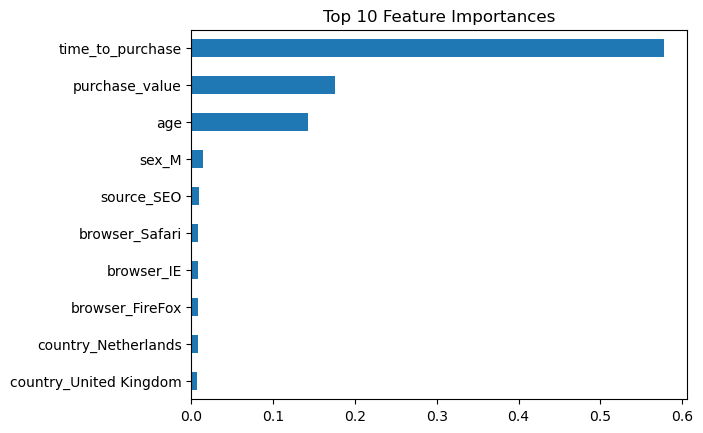

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

# Plot
feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

# ✅ Observation:
# The most important feature by far is time_to_purchase.

# It dominates all other variables (~60% importance),
# meaning the delay between signup and purchase is the strongest fraud signal.

# ✅ Other important features:
# - purchase_value
# - age

# These have moderate importance and contribute to fraud detection.

# ⚠️ Low importance features:
# - sex
# - source
# - browser
# - country

# These variables have minimal impact on the model.

# 🎯 Key insight:
# Fraudulent users behave differently in terms of timing:
# → They tend to purchase much faster after signup.

# This confirms the SQL analysis where time patterns were strong indicators.

# ✅ Business interpretation:
# - Fast purchases after signup = high fraud risk
# - High purchase values also increase risk
# - Demographics (age, sex) play a smaller role

# ✅ Conclusion:
# Behavioral features (time, value) are much more predictive than demographic or technical features.